In [1]:
import os
from PIL import Image
import numpy as np
 

X = []
y = []

basepath='./lemon-melon-classifier/dataset/'
for folder in os.scandir(basepath):
    if folder.is_dir():
        for imfile in os.scandir(folder.path):
            image = Image.open(imfile.path)
            image = np.array(image.resize((120,120))) / 255.0
            X.append(image)
            y.append(folder.name)
print(np.shape(X))
X = np.array(X)
print(y)

(42, 120, 120, 3)
['lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'lemon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon', 'melon']


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import LabelEncoder


In [3]:
Y = LabelEncoder().fit_transform(y)
Y = np.array(Y)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [5]:

import random

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

cnnModel = Sequential()

cnnModel.add(Conv2D(10, (3,3), activation="relu", input_shape=(120,120,3)))
cnnModel.add(MaxPooling2D((2,2)))
cnnModel.add(Conv2D(64, (3,3), activation="relu"))
cnnModel.add(MaxPooling2D((2,2)))
cnnModel.add(Conv2D(64, (3,3), activation="relu"))
cnnModel.add(Flatten())
cnnModel.add(Dense(64, activation="relu"))
cnnModel.add(Dense(32, activation="relu"))
cnnModel.add(Dense(1, activation="sigmoid"))
cnnModel.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 118, 118, 10)      280       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 59, 59, 10)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 57, 57, 64)        5824      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 28, 28, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 26, 26, 64)        36928     
                                                                 
 flatten_1 (Flatten)         (None, 43264)            

In [6]:
cnnModel.compile(optimizer="Adam", loss="binary_crossentropy",metrics=["accuracy"])
cnnModel.fit(X_train, y_train, epochs=20, batch_size=2)
testLoss, testAccuracy = cnnModel.evaluate(X_test, y_test)
print(testAccuracy)


Epoch 1/20


17/17 [==============================] - 3s 78ms/step - loss: 0.6708 - accuracy: 0.6061
Epoch 2/20
17/17 [==============================] - 1s 59ms/step - loss: 0.2375 - accuracy: 0.8788
Epoch 3/20
17/17 [==============================] - 1s 56ms/step - loss: 0.0576 - accuracy: 1.0000
Epoch 4/20
17/17 [==============================] - 1s 55ms/step - loss: 0.0299 - accuracy: 1.0000
Epoch 5/20
17/17 [==============================] - 1s 58ms/step - loss: 7.0903e-05 - accuracy: 1.0000
Epoch 6/20
17/17 [==============================] - 1s 54ms/step - loss: 2.6563e-06 - accuracy: 1.0000
Epoch 7/20
17/17 [==============================] - 1s 57ms/step - loss: 1.3831e-06 - accuracy: 1.0000
Epoch 8/20
17/17 [==============================] - 1s 54ms/step - loss: 1.1620e-06 - accuracy: 1.0000
Epoch 9/20
17/17 [==============================] - 1s 60ms/step - loss: 1.0227e-06 - accuracy: 1.0000
Epoch 10/20
17/17 [==============================] - 1s 60ms/step - loss: 9.5354e-07 -

In [7]:
y_pred = (cnnModel.predict(X_test) > 0.5).astype("int32")

1/1 [==============================] - 0s 207ms/step


print(y_pred)

<Axes: >

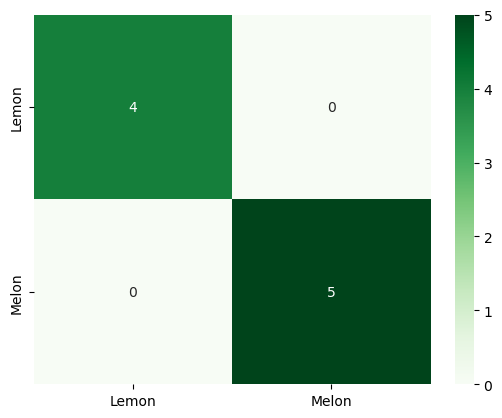

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,cmap='Greens', annot=True, xticklabels = ["Lemon", "Melon"],yticklabels = ["Lemon", "Melon"])


In [ ]:
from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

pred_prob = cnnModel.predict(X_test)
pr1, tpr1, thresh1 = roc_curve(y_test, pred_prob, pos_label=1)


random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)

plt.plot(pr1, tpr1, linestyle='--', label='CNN')
plt.plot(p_fpr, p_tpr, linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

https://www.analyticsvidhya.com/blog/2020/06/auc-roc-curve-machine-learning/